In [11]:
import numpy as np
import pandas as pd
movies = pd.read_csv('movies.csv')
ipl = pd.read_csv('ipl-matches.csv')
students = pd.DataFrame(
    {
        'name':['nitish','ankit','rupesh',np.nan,'mrityunjay',np.nan,'rishabh',np.nan,'aditya',np.nan],
        'college':['bit','iit','vit',np.nan,np.nan,'vlsi','ssit',np.nan,np.nan,'git'],
        'branch':['eee','it','cse',np.nan,'me','ce','civ','cse','bio',np.nan],
        'cgpa':[6.66,8.25,6.41,np.nan,5.6,9.0,7.4,10,7.4,np.nan],
        'package':[4,5,6,np.nan,6,7,8,9,np.nan,np.nan]

    }
)
batsman = pd.read_csv('batsman_runs_ipl.csv')
marks = {
    'maths':67,
    'english':57,
    'science':89,
    'hindi':100
}
marks_series = pd.Series(marks)

Important DataFrame Functions

1. astype --> Change the data type of given column

In [3]:
print(ipl.info())
ipl['ID'] = ipl['ID'].astype('int32')
print(ipl.info())

<class 'pandas.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               950 non-null    int64  
 1   City             899 non-null    str    
 2   Date             950 non-null    str    
 3   Season           950 non-null    str    
 4   MatchNumber      950 non-null    str    
 5   Team1            950 non-null    str    
 6   Team2            950 non-null    str    
 7   Venue            950 non-null    str    
 8   TossWinner       950 non-null    str    
 9   TossDecision     950 non-null    str    
 10  SuperOver        946 non-null    str    
 11  WinningTeam      946 non-null    str    
 12  WonBy            950 non-null    str    
 13  Margin           932 non-null    float64
 14  method           19 non-null     str    
 15  Player_of_Match  946 non-null    str    
 16  Team1Players     950 non-null    str    
 17  Team2Players     950 non-nu

2. value_count (Series and DataFrame) --> Repeated rows/ Row frequency count

When the index value of two series are same then you can add it when you want

    iq  marks  package
0  100     80       10
1   90     70        7
2  120    100       14
3   80     70       14
4   80     70       14
iq   marks  package
80   70     14         2
100  80     10         1
90   70     7          1
120  100    14         1
Name: count, dtype: int64
Player_of_Match
F du Plessis         3
KA Pollard           3
SK Raina             3
JJ Bumrah            2
SR Watson            2
AB de Villiers       2
MK Pandey            2
M Vijay              2
YK Pathan            2
A Kumble             2
HH Pandya            1
JC Buttler           1
RM Patidar           1
DA Miller            1
VR Iyer              1
SP Narine            1
RD Gaikwad           1
TA Boult             1
MP Stoinis           1
KS Williamson        1
RR Pant              1
SA Yadav             1
Rashid Khan          1
AD Russell           1
KH Pandya            1
KV Sharma            1
NM Coulter-Nile      1
Washington Sundar    1
BCJ Cutting          1
DA Warner            1
MC Henriqu

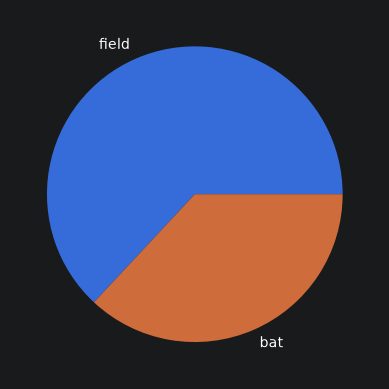

In [7]:
marks = pd.DataFrame([
    [100,80,10],
    [90,70,7],
    [120,100,14],
    [80,70,14],
    [80,70,14]
],columns=['iq','marks','package'])
print(marks)
print(marks.value_counts())

#Question 1. find which player has won most potm -> in finals and qualifiers
print(ipl[~ipl['MatchNumber'].str.isdigit()]['Player_of_Match'].value_counts())

#Question 2. Toss decision plot
print(ipl['TossDecision'].value_counts().plot(kind='pie'))

# how many matches each team has played
print((ipl['Team2'].value_counts() + ipl['Team1'].value_counts()).sort_values(ascending=False))

3. sort_values(series and dataframe) ->

Ascending -> na_position -> inplace -> multiple cols

na_position means position of nan/missing values and inplace is for permanent changes.

In [7]:
print(movies.sort_values('title_x'))  # Ascending Order
print(movies.sort_values('title_x',ascending=False))  # Descending Order
print(students.sort_values('name',na_position='first',ascending=False))
print(movies.sort_values(['year_of_release','title_x'],ascending=[True,False]))  # True for year of release and false for title x

                       title_x    imdb_id  \
1498        16 December (film)  tt0313844   
1021               1920 (film)  tt1301698   
287               1920: London  tt5638500   
723     1920: The Evil Returns  tt2222550   
1039          1971 (2007 film)  tt0983990   
...                        ...        ...   
778   Zindagi Na Milegi Dobara  tt1562872   
670          Zindagi Tere Naam  tt2164702   
756                   Zokkomon  tt1605790   
939      Zor Lagaa Ke...Haiya!  tt1479857   
1623                  Zubeidaa  tt0255713   

                                            poster_path  \
1498  https://upload.wikimedia.org/wikipedia/en/thum...   
1021  https://upload.wikimedia.org/wikipedia/en/thum...   
287   https://upload.wikimedia.org/wikipedia/en/thum...   
723   https://upload.wikimedia.org/wikipedia/en/e/e7...   
1039  https://upload.wikimedia.org/wikipedia/en/thum...   
...                                                 ...   
778   https://upload.wikimedia.org/wikipedia/e

4. rank (series) --> it is used to find rank of any column elements

In [10]:
batsman['batting_rank'] = batsman['batsman_run'].rank(ascending=False)
print(batsman.sort_values('batting_rank'))

             batter  batsman_run  batting_rank
569         V Kohli         6634           1.0
462        S Dhawan         6244           2.0
130       DA Warner         5883           3.0
430       RG Sharma         5881           4.0
493        SK Raina         5536           5.0
..              ...          ...           ...
570  V Pratap Singh            0         594.0
63     Abdur Razzak            0         594.0
562          U Kaul            0         594.0
65       Akash Deep            0         594.0
57           AS Roy            0         594.0

[605 rows x 3 columns]


5. sort_index(series and dataframe) --> It is used to sort index

In [12]:
print(marks_series.sort_index())   # in ascending order on series
print(marks_series.sort_index(ascending=False))  # in descending order on series
print(movies.sort_index(ascending=False))  # Descending order on dataframe

english     57
hindi      100
maths       67
science     89
dtype: int64
science     89
maths       67
hindi      100
english     57
dtype: int64
                                   title_x     imdb_id  \
1628                              Humsafar   tt2403201   
1627                                 Daaka  tt10833860   
1626                       Sabse Bada Sukh   tt0069204   
1625                  Yeh Zindagi Ka Safar   tt0298607   
1624                 Tera Mera Saath Rahen   tt0301250   
...                                    ...         ...   
4                          Evening Shadows   tt6028796   
3                          Why Cheat India   tt8108208   
2     The Accidental Prime Minister (film)   tt6986710   
1                            Battalion 609   tt9472208   
0                 Uri: The Surgical Strike   tt8291224   

                                            poster_path  \
1628  https://upload.wikimedia.org/wikipedia/en/thum...   
1627  https://upload.wikimedia.org/wiki